# Gate 4 + Gate 5: deviation diagnostics and the Movement Attribution Map

Nothing here is hand-typed: `results/univariate/rehab24_deviation.csv` comes from
`python src/run_univariate_deviation.py`, `results/attribution_map/rehab24_attribution_map.csv`
comes from `python src/build_attribution_map.py --all` (see `next_phase_plan.md`, sections 2
and 3). Re-running either script and this notebook updates every number below.

**Gate 4** asks: does deviation-from-a-leave-subject-out-reference (`build_reference_deviation.py`)
carry usable signal at all, per (phase, joint)? **Gate 5** fuses that with what the model
actually relies on (out-of-fold SHAP on the `biophases` feature family) into one matrix per
exercise: `percentile(SHAP importance) x percentile(deviation effect size)`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

deviation = pd.read_csv("../results/univariate/rehab24_deviation.csv")
attribution = pd.read_csv("../results/attribution_map/rehab24_attribution_map.csv")
print(f"deviation diagnostics: {deviation.shape[0]} rows (6 exercises x 36 features)")
print(f"attribution map: {attribution.shape[0]} rows (6 exercises x up to 18 phase x joint cells)")

deviation diagnostics: 216 rows (6 exercises x 36 features)
attribution map: 108 rows (6 exercises x up to 18 phase x joint cells)


## Gate 4: strongest deviation signal per exercise

In [2]:
top_deviation = (deviation.sort_values("p")
                  .groupby("exercise").first()
                  .reset_index()[["exercise", "feature", "auc", "cohens_d", "p"]])
n_sig = deviation.groupby("exercise").apply(lambda g: (g["p"] < 0.05).sum(), include_groups=False)
top_deviation["n_sig_of_36"] = top_deviation["exercise"].map(n_sig)
print(top_deviation.to_string(index=False, formatters={
    "auc": "{:.3f}".format, "cohens_d": "{:.3f}".format, "p": "{:.4f}".format}))

exercise                             feature   auc cohens_d      p  n_sig_of_36
     ex1          deviation__ascent__r_elbow 0.301   -0.587 0.0014            9
     ex2          deviation__bottom__l_elbow 0.328   -0.534 0.0021            1
     ex3          deviation__bottom__l_elbow 0.170   -1.333 0.0000           15
     ex4 deviation__bottom__l_shoulder_angle 0.320   -0.816 0.0008            6
     ex5      deviation__descent__trunk_flex 0.721    0.548 0.0004           10
     ex6          deviation__bottom__l_ankle 0.131   -1.793 0.0000           18


Deviation signal is real but sharply exercise-dependent (ex3/ex6 have the most and
strongest significant features, ex2 the fewest) - averaging this into one project-wide number
would hide exactly the localized signal the whole project is about, so it's reported per
exercise here, not pooled.

## Gate 5: Movement Attribution Map - largest quality loss per exercise

In [3]:
top_cell = (attribution.sort_values("fusion_score", ascending=False)
            .groupby("exercise").first()
            .reset_index()[["exercise", "joint", "phase", "fusion_score",
                             "importance_percentile", "deviation_percentile"]])
print(top_cell.to_string(index=False, formatters={
    "fusion_score": "{:.3f}".format, "importance_percentile": "{:.2f}".format,
    "deviation_percentile": "{:.2f}".format}))

exercise    joint   phase fusion_score importance_percentile deviation_percentile
     Ex1     knee  ascent        0.556                  0.83                 0.67
     Ex2     knee  ascent        0.682                  0.94                 0.72
     Ex3    elbow descent        0.892                  0.94                 0.94
     Ex4 shoulder  bottom        0.787                  0.83                 0.94
     Ex5    ankle  ascent        0.833                  1.00                 0.83
     Ex6    ankle  bottom        0.944                  0.94                 1.00


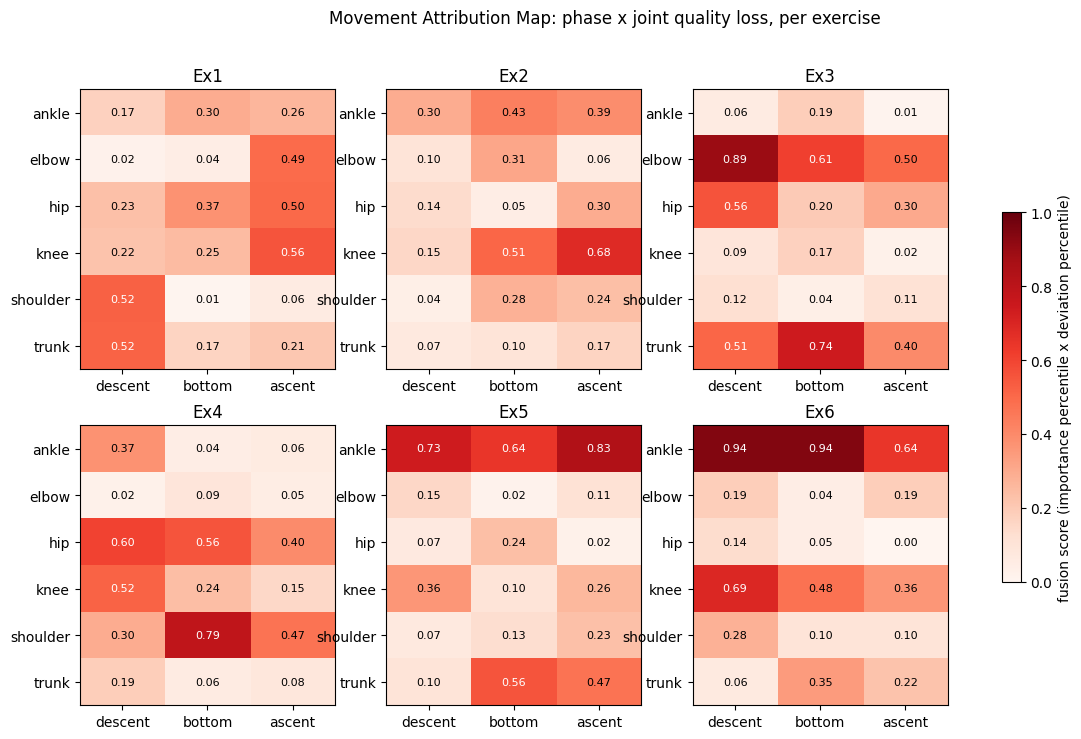

In [4]:
exercises = sorted(attribution["exercise"].unique())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, ex in zip(axes.flat, exercises):
    m = attribution[attribution["exercise"] == ex]
    pivot = m.pivot(index="joint", columns="phase", values="fusion_score")
    pivot = pivot[[c for c in ["descent", "bottom", "ascent"] if c in pivot.columns]]
    im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(ex)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val > 0.5 else "black", fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.6, label="fusion score (importance percentile x deviation percentile)")
fig.suptitle("Movement Attribution Map: phase x joint quality loss, per exercise")
plt.show()

## Honest reading

The vision doc's own illustrative example expects "Knee / Bottom" to dominate a squat's
attribution map. On Ex6 (squat) that's not quite what the map shows:

- Knee *is* the SHAP story at the whole-rep level (`knee_valgus_min` is Ex6's #1 anatomical
  feature by a clear margin - see notebook 08). Split by phase, that signal concentrates in
  **descent**, not bottom (notebook 08's own honest-reading section already caught this: rank
  8/216, not rank 1/86, from dilution alone - see `next_phase_plan.md` section 0).
- Once fused with deviation, **ankle** (descent and bottom) comes out ahead of knee for Ex6 -
  ankle deviation from the leave-subject-out reference has a very large effect size
  (Cohen's d up to ~1.4-1.8, see the Gate 4 table above) *and* the model has real SHAP weight
  on it. Knee/descent is still clearly present (3rd overall, fusion~0.69) - this isn't a
  contradiction of the knee-valgus finding, it's the fusion layer surfacing a joint that
  neither pipeline alone would have flagged as the single top signal.

This is reported as found, not adjusted to match the illustrative example - matching this
project's own standard of reporting what didn't fit the expectation as plainly as what did
(see MODEL_CARD.md's own "Known limitation" and "Honest reading" sections).